# 0. Data Import and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import warnings
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from matplotlib.colors import to_rgb
import matplotlib.colors as mcolors

warnings.filterwarnings("ignore")

## 0.1 Visual style and constants

In [3]:
BLUE = "#7EB5D6"
PINK = "#F4A8A8"
GREEN = "#A8D5A2"
YELLOW = "#F9E4A0"

CLUSTER_COLORS = [BLUE, PINK, GREEN]

INDEX_COLS = [
    "digital_engagement_index",
    "digital_experience_index",
    "emotional_loyalty_index",
    "behavioral_loyalty_index",
]

FEATURES = INDEX_COLS + ["purchase_freq_num", "online_purchase_num"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 14,
    "figure.dpi": 150,
})

## 0.2 Load data

In [4]:
df = pd.read_csv("luxury_survey_with_clusters.csv")

# Dynamic N — never hardcoded
N = len(df)
print(f"Dataset loaded: {N} respondents | {df['cluster'].nunique()} clusters\n")

Dataset loaded: 103 respondents | 3 clusters



## 0.3. Inspect cluster profiles

In [5]:
cluster_profiles = df.groupby("cluster")[FEATURES].mean().round(2)
print("Cluster mean profiles:")
print(cluster_profiles)

# Optional: colored display in notebook
cluster_profiles.style.background_gradient(cmap="RdYlGn")

Cluster mean profiles:
         digital_engagement_index  digital_experience_index  \
cluster                                                       
0                            4.03                      4.28   
1                            2.07                      2.82   
2                            4.16                      3.76   

         emotional_loyalty_index  behavioral_loyalty_index  purchase_freq_num  \
cluster                                                                         
0                           4.10                      4.17               3.22   
1                           2.47                      2.54               2.27   
2                           3.40                      3.22               1.89   

         online_purchase_num  
cluster                       
0                       3.09  
1                       2.08  
2                       2.02  


,digital_engagement_index,digital_experience_index,emotional_loyalty_index,behavioral_loyalty_index,purchase_freq_num,online_purchase_num
cluster,,,,,,
0,4.030000,4.280000,4.100000,4.170000,3.220000,3.090000
1,2.070000,2.820000,2.470000,2.540000,2.270000,2.080000
2,4.160000,3.760000,3.400000,3.220000,1.890000,2.020000


Cluster interpretation based on mean profiles:
- Cluster 0: Highest digital engagement, experience, and loyalty → "Digital Loyalists"
- Cluster 1: Lowest scores across most dimensions → "Aspirational Observers"
- Cluster 2: High digital engagement but low purchase frequency → "Digital Explorers"

## 0.4 Cluster labels

In [6]:
CLUSTER_NAMES = {
    0: "Digital Loyalists",
    1: "Aspirational Observers",
    2: "Digital Explorers",
}

df["cluster_name"] = df["cluster"].map(CLUSTER_NAMES)

# 1. Descriptive Analysis

## 1.1 Sample Overview & Composite Index Descriptive Statistics

In [7]:
print(f"Total eligible respondents: {N}")

print(f"\nAge distribution:\n{df['age_range'].value_counts()}")
print(f"\nGender distribution:\n{df['gender'].value_counts()}")
print(f"\nTop 10 countries:\n{df['country'].value_counts().head(10)}")
print(f"\nPreferred brand:\n{df['preferred_brand'].value_counts()}")
print(f"\nIncome bracket:\n{df['income'].value_counts()}")
print(
    f"\nPurchase frequency  (1=Never … 4=More than 4 times):\n"
    f"{df['purchase_freq_num'].value_counts().sort_index()}"
)
print(
    f"\nOnline purchase propensity  (1=No/would not … 4=Several times):\n"
    f"{df['online_purchase_num'].value_counts().sort_index()}"
)

print("\nComposite index descriptive statistics:")
desc = (
    df[INDEX_COLS]
    .describe()
    .T[["mean", "std", "min", "50%", "max"]]
    .rename(columns={"50%": "median"})
)
print(desc.round(3))

Total eligible respondents: 103

Age distribution:
age_range
45-54    29
18-24    24
35-44    19
25-34    17
55+      14
Name: count, dtype: int64

Gender distribution:
gender
Female    78
Male      25
Name: count, dtype: int64

Top 10 countries:
country
Spain        68
UK           10
France        6
UAE           5
USA           4
Jordan        2
Belgium       2
Mexico        2
Japan         1
Argentina     1
Name: count, dtype: int64

Preferred brand:
preferred_brand
Louis Vuitton                 27
Dior                          26
None / I switch frequently    25
Gucci                         25
Name: count, dtype: int64

Income bracket:
income
7,000€+                34
4,001–7,000€           20
I'm still a student    17
2,501–4,000€           16
Prefer not to say      10
1,500–2,500€            5
<1,500€                 1
Name: count, dtype: int64

Purchase frequency  (1=Never … 4=More than 4 times):
purchase_freq_num
1    19
2    42
3    36
4     6
Name: count, dtype: int64

Onli

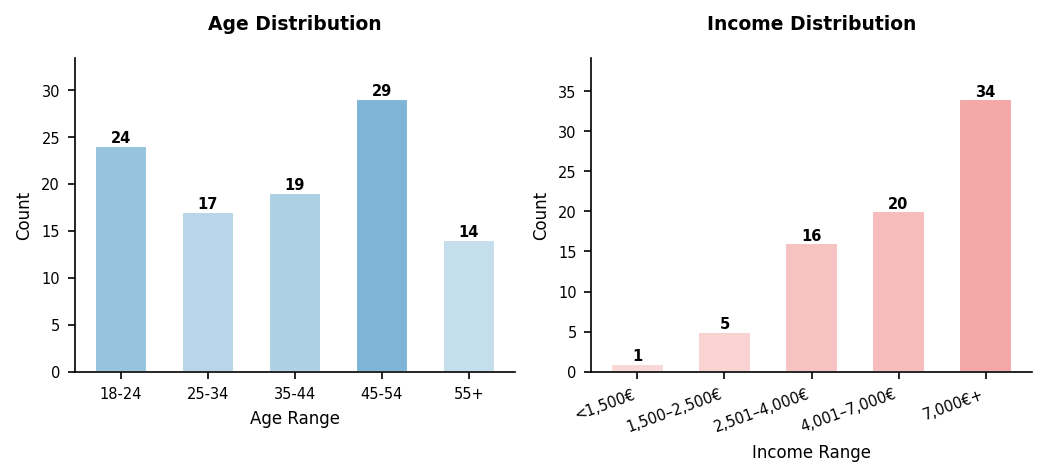


Saved → fig_sample_overview.png


In [30]:
def lighten_color(hex_color, factor=0.5):
    r, g, b = to_rgb(hex_color)
    return (1 - factor) + factor * r, (1 - factor) + factor * g, (1 - factor) + factor * b


def make_shades(values, base_color, min_factor=0.45, max_factor=1.0):
    values = np.array(values, dtype=float)
    if values.max() == values.min():
        factors = np.full(len(values), 0.8)
    else:
        factors = min_factor + (values - values.min()) / (values.max() - values.min()) * (max_factor - min_factor)
    return [lighten_color(base_color, f) for f in factors]


TITLE_SIZE = 9
LABEL_SIZE = 8
TICK_SIZE = 7
ANNOT_SIZE = 7

fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))


# -------------------------
# Age distribution
# -------------------------
age_order = ["18-24", "25-34", "35-44", "45-54", "55+"]
age_vals = df["age_range"].value_counts().reindex(age_order, fill_value=0)

age_colors = make_shades(age_vals.values, BLUE)

axes[0].bar(
    age_vals.index,
    age_vals.values,
    color=age_colors,
    edgecolor="white",
    width=0.6
)

for i, v in enumerate(age_vals.values):
    axes[0].text(i, v + 0.4, str(v), ha="center", fontsize=ANNOT_SIZE, fontweight="bold")

axes[0].set_title("Age Distribution", fontsize=TITLE_SIZE, fontweight="bold")
axes[0].set_xlabel("Age Range", fontsize=LABEL_SIZE)
axes[0].set_ylabel("Count", fontsize=LABEL_SIZE)
axes[0].tick_params(axis='both', labelsize=TICK_SIZE)
axes[0].set_ylim(0, age_vals.max() * 1.15)


# -------------------------
# Income distribution
# -------------------------
income_order = ["<1,500€", "1,500–2,500€", "2,501–4,000€", "4,001–7,000€", "7,000€+"]
income_vals = df["income"].value_counts().reindex(income_order, fill_value=0)

income_colors = make_shades(income_vals.values, PINK)

axes[1].bar(
    range(len(income_order)),
    income_vals.values,
    color=income_colors,
    edgecolor="white",
    width=0.6
)

axes[1].set_xticks(range(len(income_order)))
axes[1].set_xticklabels(income_order, rotation=20, ha="right", fontsize=TICK_SIZE)

for i, v in enumerate(income_vals.values):
    axes[1].text(i, v + 0.4, str(v), ha="center", fontsize=ANNOT_SIZE, fontweight="bold")

axes[1].set_title("Income Distribution", fontsize=TITLE_SIZE, fontweight="bold")
axes[1].set_xlabel("Income Range", fontsize=LABEL_SIZE)
axes[1].set_ylabel("Count", fontsize=LABEL_SIZE)
axes[1].tick_params(axis='both', labelsize=TICK_SIZE)
axes[1].set_ylim(0, income_vals.max() * 1.15)


plt.tight_layout(pad=0.8)

plt.savefig("fig_sample_overview.png", dpi=120, bbox_inches="tight")

plt.show()
plt.close()

print("\nSaved → fig_sample_overview.png")

## 1.2 Distribution of Composite Loyalty Indices

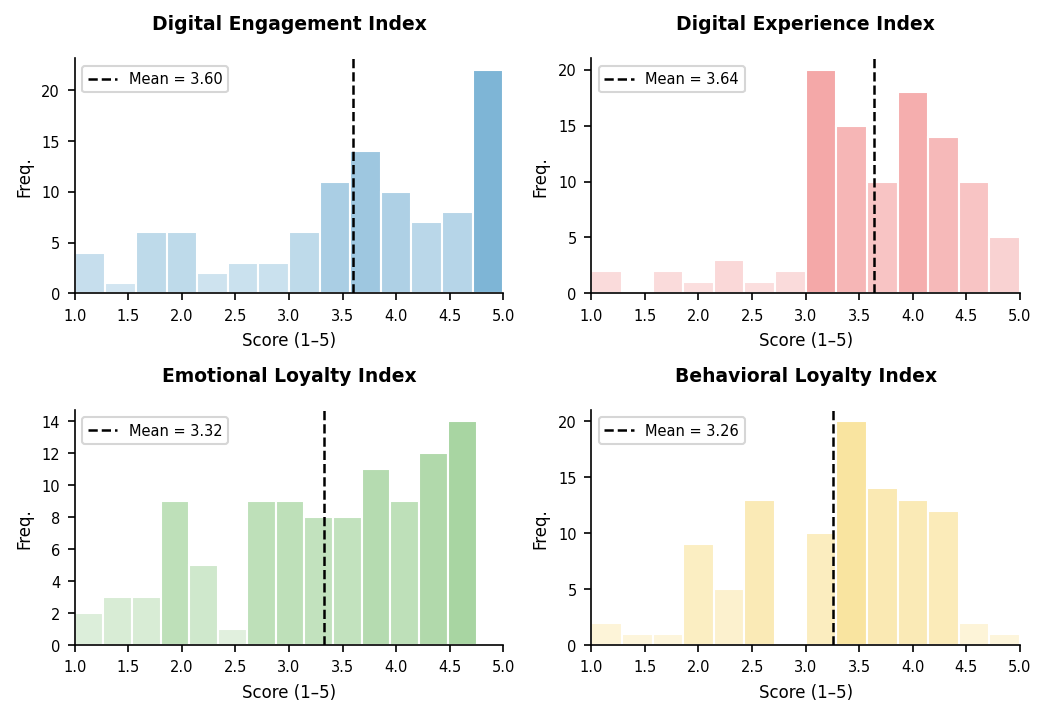

Saved → fig_index_distributions.png


In [31]:
def lighten_color(hex_color, factor=0.5):
    r, g, b = to_rgb(hex_color)
    return (
        (1 - factor) + factor * r,
        (1 - factor) + factor * g,
        (1 - factor) + factor * b
    )


def make_shades(values, base_color, min_factor=0.35, max_factor=1.0):
    values = np.array(values, dtype=float)

    if values.max() == values.min():
        factors = np.full(len(values), 0.8)
    else:
        factors = min_factor + (values - values.min()) / (values.max() - values.min()) * (max_factor - min_factor)

    return [lighten_color(base_color, f) for f in factors]


TITLE_SIZE = 9
LABEL_SIZE = 8
TICK_SIZE = 7
LEGEND_SIZE = 7


fig, axes = plt.subplots(2, 2, figsize=(7, 4.8))

panel_labels = [
    "Digital Engagement Index",
    "Digital Experience Index",
    "Emotional Loyalty Index",
    "Behavioral Loyalty Index",
]

panel_colors = [BLUE, PINK, GREEN, YELLOW]


for ax, col, label, base_color in zip(axes.flat, INDEX_COLS, panel_labels, panel_colors):

    data = df[col].dropna()

    counts, bins, patches = ax.hist(
        data,
        bins=14,
        edgecolor="white"
    )

    bin_colors = make_shades(counts, base_color)

    for patch, c in zip(patches, bin_colors):
        patch.set_facecolor(c)
        patch.set_alpha(1.0)

    mean_val = data.mean()

    ax.axvline(
        mean_val,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"Mean = {mean_val:.2f}",
    )

    ax.set_title(label, fontsize=TITLE_SIZE, fontweight="bold")
    ax.set_xlabel("Score (1–5)", fontsize=LABEL_SIZE)
    ax.set_ylabel("Freq.", fontsize=LABEL_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.set_xlim(1, 5)
    ax.legend(fontsize=LEGEND_SIZE)


plt.tight_layout(pad=0.8)

plt.savefig(
    "fig_index_distributions.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved → fig_index_distributions.png")

## 1.3 Purchase Behaviour Metrics by Preferred Brand

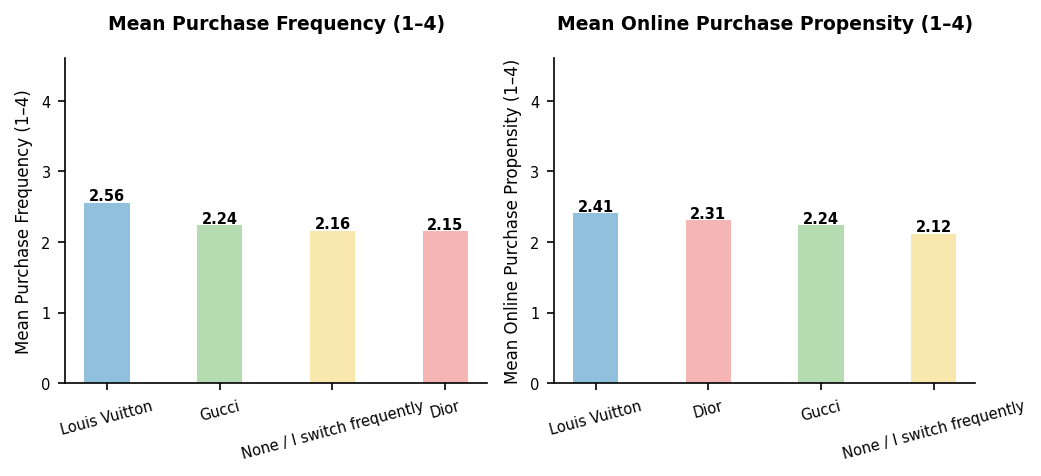

Saved → fig_brand_purchase_behaviour.png


In [29]:
BRAND_COLORS = {
    "Louis Vuitton": BLUE,
    "Gucci": GREEN,
    "Dior": PINK,
    "None / I switch frequently": YELLOW
}

TITLE_SIZE = 9
LABEL_SIZE = 8
TICK_SIZE = 7
ANNOT_SIZE = 7

brand_means = df.groupby("preferred_brand")[
    ["purchase_freq_num", "online_purchase_num"]
].mean()

fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))

metric_labels = [
    "Mean Purchase Frequency (1–4)",
    "Mean Online Purchase Propensity (1–4)",
]

for ax, col, label in zip(
    axes, ["purchase_freq_num", "online_purchase_num"], metric_labels
):

    vals = brand_means[col].sort_values(ascending=False)
    colors = [BRAND_COLORS[b] for b in vals.index]

    bars = ax.bar(
        vals.index,
        vals.values,
        color=colors,
        alpha=0.85,
        width=0.4
    )

    for bar, val in zip(bars, vals.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.03,
            f"{val:.2f}",
            ha="center",
            fontsize=ANNOT_SIZE,
            fontweight="bold"
        )

    ax.set_ylabel(label, fontsize=LABEL_SIZE)
    ax.set_title(label, fontsize=TITLE_SIZE, fontweight="bold")
    ax.set_ylim(0, 4.6)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout(pad=0.8)

plt.savefig("fig_brand_purchase_behaviour.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

print("Saved → fig_brand_purchase_behaviour.png")

## 1.4 Pearson Correlation Heatmap

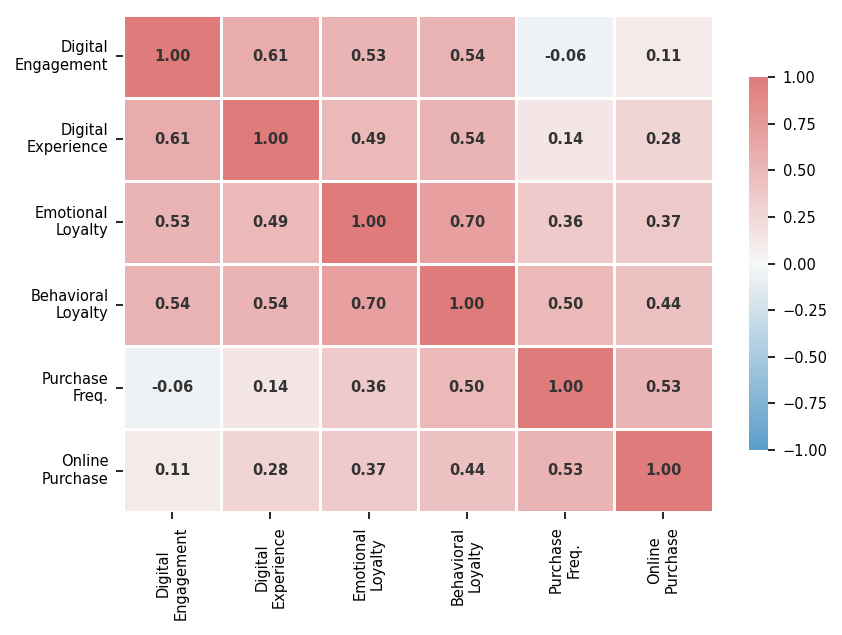

Saved → fig_correlation_heatmap.png


In [33]:
HEAT_BLUE = "#5B9EC9"
HEAT_PINK = "#E07B7B"

TITLE_SIZE = 9
LABEL_SIZE = 8
TICK_SIZE = 7

corr_vars = INDEX_COLS + ["purchase_freq_num", "online_purchase_num"]
corr_matrix = df[corr_vars].corr()

corr_labels = [
    "Digital\nEngagement",
    "Digital\nExperience",
    "Emotional\nLoyalty",
    "Behavioral\nLoyalty",
    "Purchase\nFreq.",
    "Online\nPurchase",
]

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "corr_map",
    [HEAT_BLUE, "#F7F7F7", HEAT_PINK]
)

fig, ax = plt.subplots(figsize=(5.8, 4.2))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.6,
    linecolor="white",
    xticklabels=corr_labels,
    yticklabels=corr_labels,
    annot_kws={"size": 7, "weight": "bold", "color": "#333333"},
    cbar_kws={"shrink": 0.75},
    ax=ax,
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)

ax.tick_params(axis='both', labelsize=TICK_SIZE)

plt.tight_layout(pad=0.6)

plt.savefig("fig_correlation_heatmap.png", dpi=120, bbox_inches="tight")

plt.show()
plt.close()

print("Saved → fig_correlation_heatmap.png")

# 2. Quantitative model results

## 2.1 H1 — K-Means Consumer Segmentation

In [ ]:
# Cluster sizes — computed dynamically, never hardcoded
cluster_counts = df["cluster"].value_counts().sort_index()
print(f"\nCluster sizes:\n{cluster_counts}")
print(f"\nCluster sizes (%):\n{(cluster_counts / N * 100).round(1)}")

# IMPORTANT: inspect these profiles BEFORE confirming cluster names above
cluster_profiles = df.groupby("cluster")[FEATURES].mean().round(3)
cluster_profiles.index = cluster_profiles.index.map(CLUSTER_NAMES)
print("\nCluster mean profiles — verify these match the assigned names:")
print(cluster_profiles.T.to_string())

print("\nAge breakdown by cluster (%):")
print(
    (df.groupby("cluster_name")["age_range"]
       .value_counts(normalize=True) * 100)
    .round(1).to_string()
)
print("\nMean income by cluster (ordinal 1–5):")
print(df.groupby("cluster_name")["income_num"].mean().round(2))

print("\nPreferred brand by cluster (%):")
print(
    (df.groupby("cluster_name")["preferred_brand"]
       .value_counts(normalize=True) * 100)
    .round(1).to_string()
)


Cluster sizes:
cluster
0    23
1    26
2    54
Name: count, dtype: int64

Cluster sizes (%):
cluster
0    22.3
1    25.2
2    52.4
Name: count, dtype: float64

Cluster mean profiles — verify these match the assigned names:
cluster                   Digital Loyalists  Aspirational Observers  Digital Explorers
digital_engagement_index              4.033                   2.067              4.157
digital_experience_index              4.283                   2.817              3.764
emotional_loyalty_index               4.098                   2.471              3.403
behavioral_loyalty_index              4.174                   2.538              3.216
purchase_freq_num                     3.217                   2.269              1.889
online_purchase_num                   3.087                   2.077              2.019

Age breakdown by cluster (%):
cluster_name            age_range
Aspirational Observers  55+          34.6
                        45-54        23.1
                  

### 2.1.1 Radar Chart: Cluster Profiles

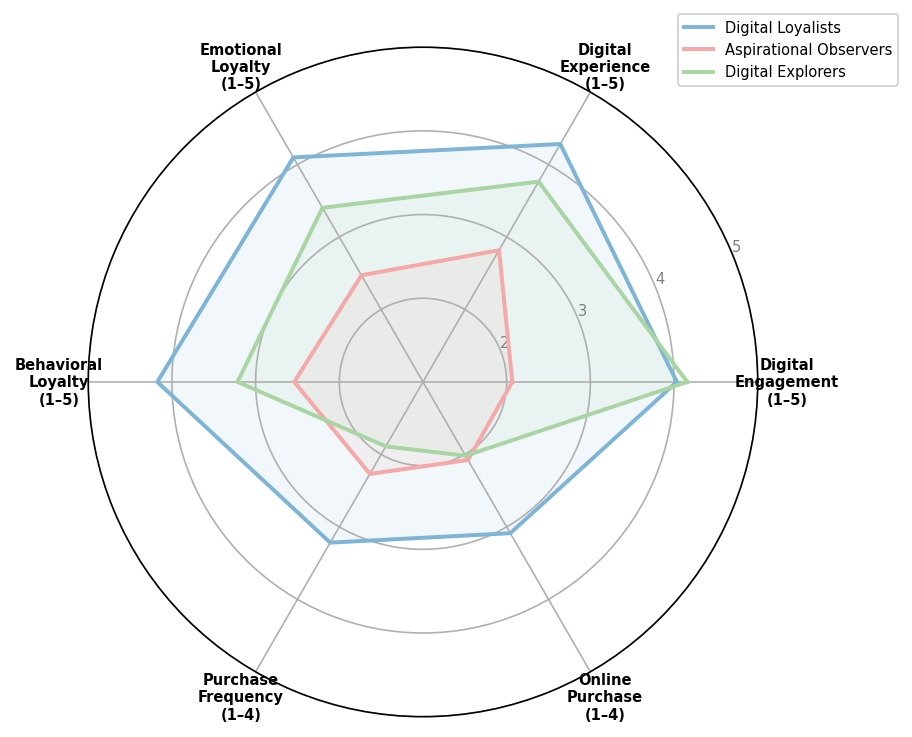


Saved → fig_radar_clusters.png


In [27]:
categories = [
    "Digital\nEngagement\n(1–5)",
    "Digital\nExperience\n(1–5)",
    "Emotional\nLoyalty\n(1–5)",
    "Behavioral\nLoyalty\n(1–5)",
    "Purchase\nFrequency\n(1–4)",
    "Online\nPurchase\n(1–4)",
]

TICK_SIZE = 7
LEGEND_SIZE = 7

N_axes = len(categories)
angles = [n / float(N_axes) * 2 * np.pi for n in range(N_axes)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6.2, 5.0), subplot_kw=dict(polar=True))

for cluster_id, color in zip(sorted(df["cluster"].unique()), CLUSTER_COLORS):
    raw = df.groupby("cluster")[FEATURES].mean().loc[cluster_id].values.tolist()
    values = raw + raw[:1]
    ax.plot(angles, values, color=color, linewidth=1.9, label=CLUSTER_NAMES[cluster_id])
    ax.fill(angles, values, color=color, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=TICK_SIZE, fontweight="bold")

ax.set_ylim(1, 5)
ax.set_yticks([2, 3, 4, 5])
ax.set_yticklabels(["2", "3", "4", "5"], size=TICK_SIZE, color="grey")

ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.06), fontsize=LEGEND_SIZE)

plt.tight_layout(pad=1.0)

plt.savefig("fig_radar_clusters.png", dpi=150, bbox_inches="tight")

plt.show()

plt.close()

print("\nSaved → fig_radar_clusters.png")

### 2.1.2 Bar Chart: Cluster Size Distribution

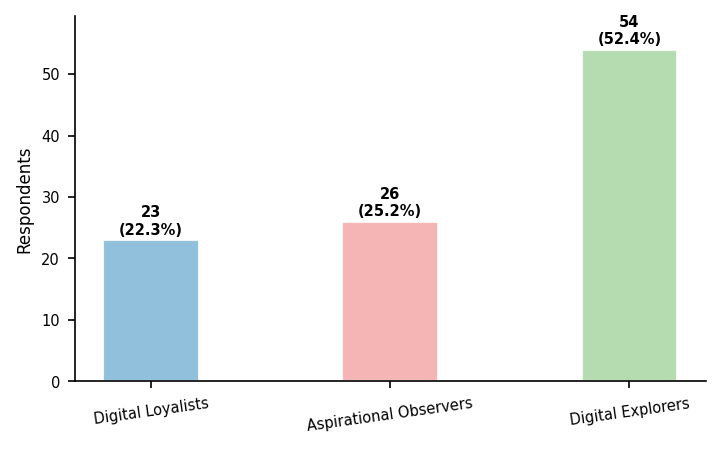

Saved → fig_cluster_size_bar.png


In [34]:
cluster_counts = df["cluster"].value_counts().to_dict()
N = len(df)

TITLE_SIZE = 9
LABEL_SIZE = 8
TICK_SIZE = 7
ANNOT_SIZE = 7

ordered_ids = sorted(df["cluster"].unique())
ordered_names = [CLUSTER_NAMES[i] for i in ordered_ids]
ordered_counts = [cluster_counts[i] for i in ordered_ids]
ordered_pcts = [cluster_counts[i] / N * 100 for i in ordered_ids]

fig, ax = plt.subplots(figsize=(4.8, 3.0))

bars = ax.bar(
    ordered_names,
    ordered_counts,
    color=CLUSTER_COLORS,
    alpha=0.85,
    edgecolor="white",
    width=0.4
)

for bar, count, pct in zip(bars, ordered_counts, ordered_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{count}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=ANNOT_SIZE,
        fontweight="bold",
    )

ax.set_ylabel("Respondents", fontsize=LABEL_SIZE)
ax.tick_params(axis="both", labelsize=TICK_SIZE)
ax.tick_params(axis="x", rotation=8)

ax.set_ylim(0, max(ordered_counts) * 1.1)

plt.tight_layout(pad=0.7)

plt.savefig("fig_cluster_size_bar.png", dpi=120, bbox_inches="tight")

plt.show()
plt.close()

print("Saved → fig_cluster_size_bar.png")

### 2.1.3 Standardised Profile Heatmap (z-scores)

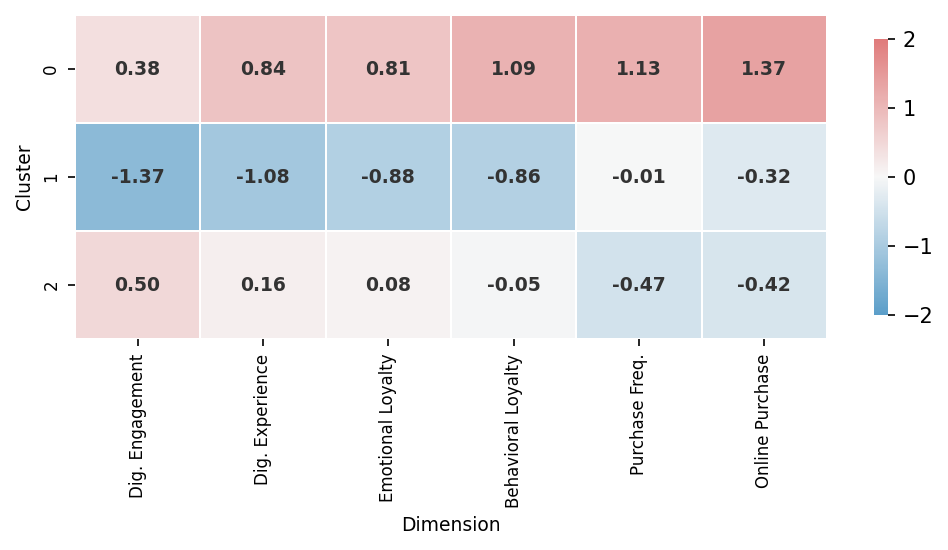

Saved → fig_standardised_profiles.png


In [24]:
HEAT_BLUE = "#5B9EC9"
HEAT_PINK = "#E07B7B"

TITLE_SIZE = 11
LABEL_SIZE = 9
TICK_SIZE = 8

overall_mean = df[FEATURES].mean()
overall_std = df[FEATURES].std()
z_profiles = (cluster_profiles[FEATURES] - overall_mean) / overall_std

z_labels = [
    "Dig. Engagement",
    "Dig. Experience",
    "Emotional Loyalty",
    "Behavioral Loyalty",
    "Purchase Freq.",
    "Online Purchase",
]

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "cluster_map",
    [HEAT_BLUE, "#F7F7F7", HEAT_PINK]
)

fig, ax = plt.subplots(figsize=(7, 3.8))

sns.heatmap(
    z_profiles,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0,
    vmin=-2,
    vmax=2,
    linewidths=0.8,
    linecolor="white",
    xticklabels=z_labels,
    annot_kws={"size": 9, "weight": "bold", "color": "#333333"},
    cbar_kws={"shrink": 0.85},
    ax=ax,
)

ax.set_xlabel("Dimension", fontsize=LABEL_SIZE)
ax.set_ylabel("Cluster", fontsize=LABEL_SIZE)
ax.tick_params(axis="both", labelsize=TICK_SIZE)

plt.tight_layout(pad=1.2)

plt.savefig("fig_standardised_profiles.png", dpi=150, bbox_inches="tight")

plt.show()

plt.close()

print("Saved → fig_standardised_profiles.png")

## 2.2 H2 — OLS Regression: Predictors of Behavioral Loyalty

In [ ]:
import statsmodels.api as sm

reg_df = df[
    ["digital_engagement_index", "digital_experience_index",
     "emotional_loyalty_index", "behavioral_loyalty_index"]
].dropna()

X_names = [
    "digital_engagement_index",
    "digital_experience_index",
    "emotional_loyalty_index",
]

X = reg_df[X_names]
y = reg_df["behavioral_loyalty_index"]

# Add constant (intercept)
X = sm.add_constant(X)

# Run regression
model = sm.OLS(y, X).fit()

# Print academic summary table
print(model.summary())

with open("ols_regression_results.txt", "w") as f:
    f.write(model.summary().as_text())
print("Saved → ols_regression_results.txt")

                               OLS Regression Results                               
Dep. Variable:     behavioral_loyalty_index   R-squared:                       0.555
Model:                                  OLS   Adj. R-squared:                  0.541
Method:                       Least Squares   F-statistic:                     41.15
Date:                      Mon, 06 Apr 2026   Prob (F-statistic):           2.37e-17
Time:                              14:43:09   Log-Likelihood:                -85.045
No. Observations:                       103   AIC:                             178.1
Df Residuals:                            99   BIC:                             188.6
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

### 2.2.1 Scatter: Digital Engagement vs Behavioral Loyalty

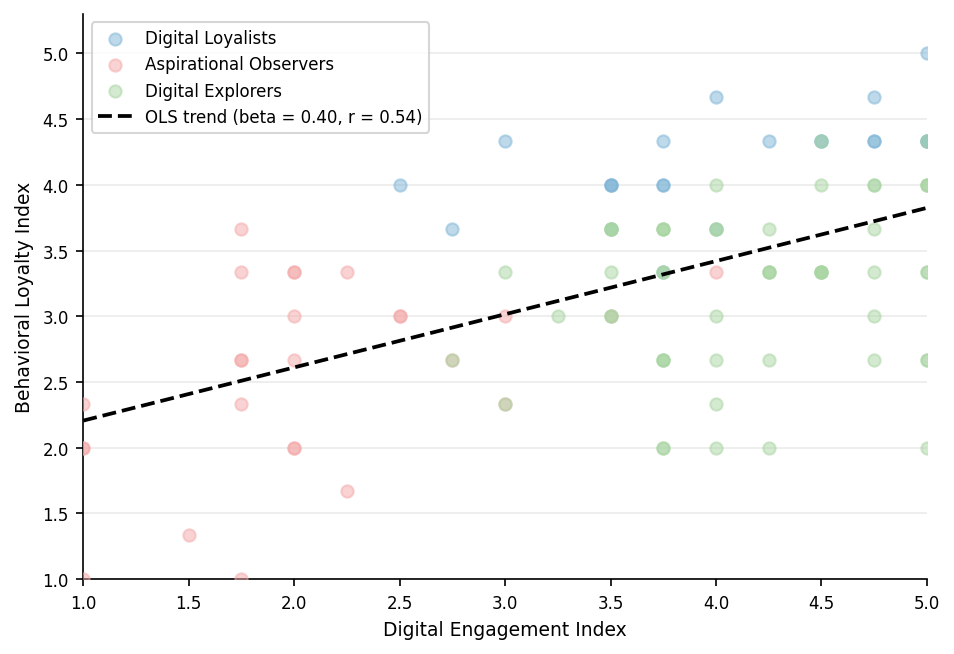


Saved → fig_regression_scatter.png


In [25]:
scatter_df = df[["digital_engagement_index", "behavioral_loyalty_index", "cluster"]].dropna()

TITLE_SIZE = 11
LABEL_SIZE = 9
TICK_SIZE = 8
LEGEND_SIZE = 8

fig, ax = plt.subplots(figsize=(6.5, 4.5))

for cluster_id, color in zip(sorted(scatter_df["cluster"].unique()), CLUSTER_COLORS):
    sub = scatter_df[scatter_df["cluster"] == cluster_id]
    ax.scatter(
        sub["digital_engagement_index"],
        sub["behavioral_loyalty_index"],
        alpha=0.50,
        color=color,
        label=CLUSTER_NAMES[cluster_id],
        s=35,
        zorder=3,
    )

m, b_line = np.polyfit(
    scatter_df["digital_engagement_index"],
    scatter_df["behavioral_loyalty_index"],
    1,
)

r_full, _ = pearsonr(
    scatter_df["digital_engagement_index"],
    scatter_df["behavioral_loyalty_index"],
)

x_line = np.linspace(1, 5, 100)

ax.plot(
    x_line,
    m * x_line + b_line,
    "k--",
    linewidth=1.8,
    label=f"OLS trend (beta = {m:.2f}, r = {r_full:.2f})",
    zorder=4,
)

ax.set_xlabel("Digital Engagement Index", fontsize=LABEL_SIZE)
ax.set_ylabel("Behavioral Loyalty Index", fontsize=LABEL_SIZE)

ax.set_xlim(1, 5)
ax.set_ylim(1, 5.3)

ax.tick_params(axis="both", labelsize=TICK_SIZE)
ax.legend(fontsize=LEGEND_SIZE)

ax.grid(axis="y", alpha=0.25)

plt.tight_layout(pad=1.2)

plt.savefig("fig_regression_scatter.png", dpi=150, bbox_inches="tight")

plt.show()

plt.close()

print("\nSaved → fig_regression_scatter.png")

## 2.3 Statistical Summary Export

In [ ]:
summary_lines = [
    "=== CHAPTER V — STATISTICAL SUMMARY ===",
    f"N = {N}",                              # dynamic
    "",
    "--- 1.1  Index Descriptive Statistics ---",
]
for col in INDEX_COLS:
    summary_lines.append(
        f"  {col}: M = {df[col].mean():.3f},  SD = {df[col].std():.3f}"
    )

summary_lines += ["", "--- 2.1  Cluster Profiles (mean scores) ---"]
for cid in sorted(df["cluster"].unique()):
    n_c = cluster_counts[cid]                # dynamic
    pct = n_c / N * 100                      # dynamic
    summary_lines.append(f"\n  [{CLUSTER_NAMES[cid]}]  n = {n_c}  ({pct:.1f}%)")
    for feat in FEATURES:
        summary_lines.append(
            f"    {feat}: {df[df['cluster'] == cid][feat].mean():.3f}"
        )

summary_lines += [
    "",
    "--- 2.2  OLS Regression (DV = Behavioral Loyalty) ---",
    f"  R-squared = {model.rsquared:.4f}   |   Adj. R-squared = {model.rsquared_adj:.4f}",
    f"  F-statistic = {model.fvalue:.4f}   (p = {model.f_pvalue:.4f})",
]
for name in X_names:
    summary_lines.append(
        f"  {name}: beta = {model.params[name]:.4f},  p = {model.pvalues[name]:.4f}"
    )

summary_lines += ["", "--- Pearson Correlations with Behavioral Loyalty ---"]
for col in X_names:
    # FIX: paired dropna()
    temp = df[[col, "behavioral_loyalty_index"]].dropna()
    r_val, p_val = pearsonr(temp[col], temp["behavioral_loyalty_index"])
    summary_lines.append(f"  {col}: r = {r_val:.4f},  p = {p_val:.4f}")


with open("chapter5_stats_summary.txt", "w") as f:
    f.write("\n".join(summary_lines))
print("\nSaved → chapter5_stats_summary.txt")
print("\nAll Chapter V outputs generated successfully.")


Saved → chapter5_stats_summary.txt

All Chapter V outputs generated successfully.
